In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from langdetect import detect
import re
import emoji
from pathlib import Path
import os

In [8]:
# ================= PROJECT ROOT & DATA PATHS =================
try:
    PROJECT_ROOT = Path(__file__).resolve().parent
except NameError:
    PROJECT_ROOT = Path.cwd()  # fallback if running interactively

DEFAULT_DATA_DIR = Path(r"C:/Users/DELL/Documents/project_data/output")
DATA_DIR = Path(os.getenv("DATA_DIR", DEFAULT_DATA_DIR))

POSTS_PATH = DATA_DIR / "safaricom_posts.csv"
COMMENTS_PATH = DATA_DIR / "safaricom_comments22.csv"

# ================= FILE EXISTENCE CHECK =================
print("Using DATA_DIR:", DATA_DIR)
if not POSTS_PATH.exists():
    raise FileNotFoundError(f"Posts file not found: {POSTS_PATH}")
if not COMMENTS_PATH.exists():
    raise FileNotFoundError(f"Comments file not found: {COMMENTS_PATH}")

# ================= LOAD CSVs =================
posts = pd.read_csv(POSTS_PATH)
comments = pd.read_csv(COMMENTS_PATH)


comments_sent = comments[[ 'text']].dropna()

#================== DATA INSPECTION =================
print("\n=== BEFORE PREPROCESSING ===")
print(f"Posts shape: {posts.shape}")
print(f"Comments shape: {comments.shape}")
print("\nPosts columns:", posts.columns.tolist())
print("Comments columns:", comments.columns.tolist())

print("\n------ For Sentiment Analysis ------")
print(f"Comments shape: {comments_sent.shape}")


Using DATA_DIR: C:\Users\DELL\Documents\project_data\output

=== BEFORE PREPROCESSING ===
Posts shape: (1948, 11)
Comments shape: (286376, 5)

Posts columns: ['msg_id', 'date_utc', 'text', 'views', 'forwards', 'replies', 'has_media', 'media_type', 'sender_id', 'reply_to_msg_id', 'num_comments']
Comments columns: ['post_id', 'comment_id', 'date_utc', 'text', 'sender_id']

------ For Sentiment Analysis ------
Comments shape: (279536, 1)


In [9]:
# ================= FILL MISSING VALUES =================
posts['media_type'] = posts['media_type'].fillna('Unknown')
posts['text'] = posts['text'].fillna('<media_only>')
posts['reply_to_msg_id'] = posts['reply_to_msg_id'].fillna('None')

comments['text'] = comments['text'].fillna('<deleted>')

=== EMOJI / TEXT DISTRIBUTION ===
text_only         :    136,369 ( 47.62%)
emoji_with_text   :    127,216 ( 44.42%)
emoji_only        :     21,748 (  7.59%)
other             :      1,043 (  0.36%)


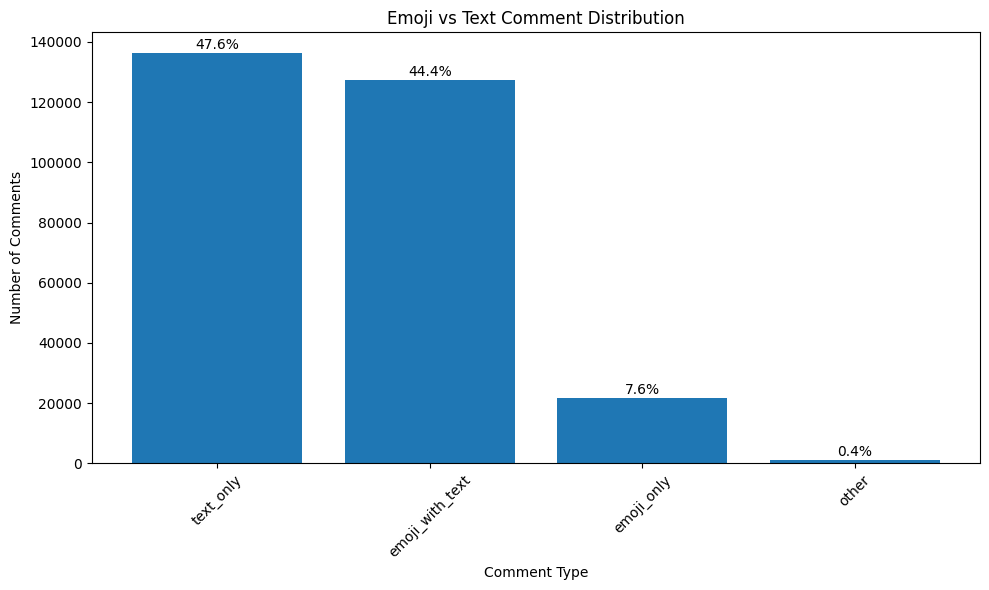

In [12]:
# ==========================================================
# EMOJI DETECTION + CONVERSION + CLEAN MODEL TEXT (ONE CELL)
# Works with ANY emoji package version (no deprecated calls)
# ==========================================================

import pandas as pd
import regex as re
import emoji
import matplotlib.pyplot as plt

# ------------------------------
# 1. Unicode-safe patterns
# ------------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

# Official Unicode emoji property (correct way)
EMOJI_RE = re.compile(r'\p{Emoji}', re.UNICODE)

# ------------------------------
# 2. Classify comment type
# ------------------------------
def classify_emoji_text(text: str) -> str:
    if not isinstance(text, str) or text.strip() == "":
        return "empty"

    text = text.strip()

    has_emoji = bool(EMOJI_RE.search(text))
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))

    if has_emoji and not (has_amharic or has_english):
        return "emoji_only"
    elif has_emoji and (has_amharic or has_english):
        return "emoji_with_text"
    elif has_amharic or has_english:
        return "text_only"
    else:
        return "other"

# ------------------------------
# 3. Emoji → semantic words
# ------------------------------
def demojize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = emoji.demojize(text, delimiters=(" ", " "))
    text = text.replace("_", " ").replace(":", "")
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ------------------------------
# 4. Final modeling text
# ------------------------------
def final_clean_text(text: str) -> str:
    text = demojize_text(text)
    text = re.sub(r'http\S+|www\S+|@\w+', '', text)
    text = re.sub(r'[^\w\s\u1200-\u137F]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# ------------------------------
# 5. Apply to comments dataframe
# ------------------------------
comments['emoji_text_type'] = comments['text'].apply(classify_emoji_text)
comments['model_text'] = comments['text'].apply(final_clean_text)

# ------------------------------
# 6. Statistics
# ------------------------------
counts = comments['emoji_text_type'].value_counts()
percentages = counts / len(comments) * 100

print("=== EMOJI / TEXT DISTRIBUTION ===")
for label in counts.index:
    print(f"{label:18}: {counts[label]:10,} ({percentages[label]:6.2f}%)")

# ------------------------------
# 7. Visualization (matplotlib only)
# ------------------------------
plt.figure(figsize=(10,6))
plt.bar(counts.index, counts.values)
plt.xticks(rotation=45)
plt.title("Emoji vs Text Comment Distribution")
plt.xlabel("Comment Type")
plt.ylabel("Number of Comments")

for i, v in enumerate(counts.values):
    plt.text(i, v + max(counts.values)*0.01,
             f"{percentages.iloc[i]:.1f}%",
             ha='center')

plt.tight_layout()
plt.show()

=== COMMENT TYPE DISTRIBUTION ===


,count,percentage
comment_type,,
Text only,210611,73.54
Text + Emoji,52974,18.50
Empty/Other,18820,6.57
Emoji only,3971,1.39


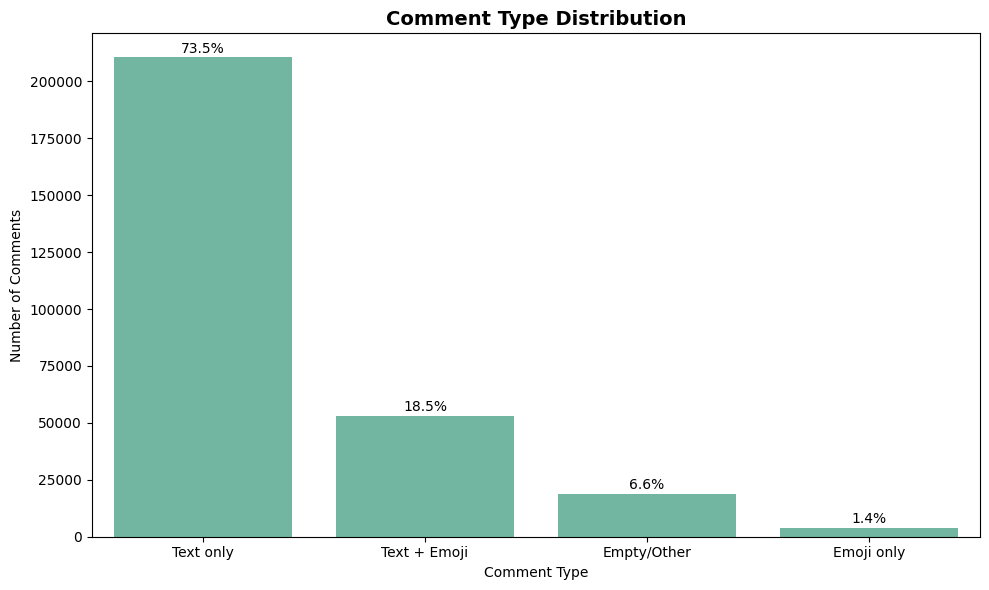

In [25]:
# ===============================
# Robust Comment Type Detection
# ===============================

import pandas as pd
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 0. Load your comments file
# ------------------------------
# comments = pd.read_csv("comments.csv")  # Uncomment if needed

# ------------------------------
# 1. Ensure 'cleaned_text' exists
# ------------------------------
if 'cleaned_text' not in comments.columns:
    comments['cleaned_text'] = comments['text'].astype(str).str.strip()

# ------------------------------
# 2. Regex for language detection
# ------------------------------
AMHARIC_RE = re.compile(r'[\u1200-\u137F]')
ENGLISH_RE = re.compile(r'[A-Za-z]')

def contains_emoji(text: str) -> bool:
    """Check if string contains at least one emoji (robust)."""
    return bool(emoji.emoji_list(text))  # returns list of emoji found

# ------------------------------
# 3. Classification function
# ------------------------------
def classify_comment_type(text: str) -> str:
    text = str(text).strip()
    
    if not text:
        return 'Empty/Other'
    
    has_amharic = bool(AMHARIC_RE.search(text))
    has_english = bool(ENGLISH_RE.search(text))
    has_text = has_amharic or has_english
    has_emoji = contains_emoji(text)
    
    if has_text and has_emoji:
        return 'Text + Emoji'
    elif has_text:
        return 'Text only'
    elif has_emoji:
        return 'Emoji only'
    else:
        return 'Empty/Other'

# ------------------------------
# 4. Apply classification
# ------------------------------
comments['comment_type'] = comments['cleaned_text'].apply(classify_comment_type)

# ------------------------------
# 5. Compute counts and percentages
# ------------------------------
comment_type_counts = comments['comment_type'].value_counts()
comment_type_percent = (comment_type_counts / len(comments) * 100).round(2)

summary_df = pd.DataFrame({
    'count': comment_type_counts,
    'percentage': comment_type_percent
}).sort_values('count', ascending=False)

print("=== COMMENT TYPE DISTRIBUTION ===")
display(summary_df)

# ------------------------------
# 6. Visualization (fixed warning)
# ------------------------------
plt.figure(figsize=(10, 6))

# Use color palette as list instead of 'palette' parameter
palette_colors = sns.color_palette('Set2', n_colors=len(summary_df))

sns.barplot(
    x=summary_df.index,
    y=summary_df['count'],
    color=palette_colors[0],  # uniform color
)

plt.title('Comment Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Comment Type')
plt.ylabel('Number of Comments')

# Annotate percentages on top of bars
for i, v in enumerate(summary_df['count']):
    pct = summary_df['percentage'].iloc[i]
    plt.text(i, v + max(summary_df['count']) * 0.01, f"{pct:.1f}%", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [24]:
# -----------------------------
# Show sample 'Empty/Other' comments
# -----------------------------
sample_empty = comments[comments['comment_type'] == 'Empty/Other']['text'].tail(10)

print("=== SAMPLE EMPTY/OTHER COMMENTS ===")
for i, txt in enumerate(sample_empty, 1):
    print(f"{i}. {txt}")

=== SAMPLE EMPTY/OTHER COMMENTS ===
1. 3,141
2. 2700
3. 3000
4. 300
5. 3000
6. 3000
7. 0722579432
8. 0722737398
9. 0723182506
10. 100%


In [ ]:
# -----------------------------
# Show all 'Empty/Other' comments horizontally
# -----------------------------
empty_comments = comments[comments['comment_type'] == 'Empty/Other']['text'].tolist()

print("=== EMPTY/OTHER COMMENTS LIST ===")
print(empty_comments)  # prints as a Python list horizontally

# Or as a nicely formatted single string separated by " | "
print("\n=== EMPTY/OTHER COMMENTS (formatted) ===")
print(" | ".join(map(str, empty_comments[:50])))  # first 50 comments for readability